# Random vs BFS 기준선

## tl;dr

- 동일한 2개 레벨 × 10개 seed에서 BFS 성공률은 100%, Random 성공률은 35%였다.
- BFS 성공 에피소드의 평균 행동 수는 3.0회였다.
- 아래 셀은 원시 결과, 집계표와 차트를 같은 설정으로 재생성한다.

## Context & Methods

두 기준선을 같은 내장 레벨과 seed 조합에서 실행한다. 환경의 `max_steps`는 모든 실행에 동일하게 적용한다.

### Key Assumptions

- 현재 비교 범위는 `tiny-push`, `tiny-walk`다.
- BFS는 primitive action 최단 경로를 완전 탐색한다.
- 실행 시간에는 Agent 초기화·계획과 행동 선택이 포함된다.

### 1. Setup

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd

from sokoban_agent.agents import BFSAgent, RandomAgent
from sokoban_agent.env import SokobanEnv
from sokoban_agent.evaluation import (
    run_benchmark,
    summarize_by_agent,
)

LEVEL_IDS = ['tiny-push', 'tiny-walk']
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
MAX_STEPS = 40

## Data

### 2. Run identical cases

In [2]:
env = SokobanEnv(max_steps=MAX_STEPS)
try:
    results = run_benchmark(
        env,
        [RandomAgent(), BFSAgent()],
        level_ids=LEVEL_IDS,
        seeds=SEEDS,
    )
finally:
    env.close()

results_df = pd.DataFrame.from_records(
    asdict(result) for result in results
)
results_df.head(8)

,agent_name,level_id,seed,success,deadlock,truncated,action_count,invalid_moves,total_reward,elapsed_seconds,failure_reason,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds
0,random,tiny-push,0,False,True,False,21,11,-12.1,0.000528,None,0,0,0,0,0,0.0
1,random,tiny-push,1,False,False,True,40,13,-4.0,0.000252,None,0,0,0,0,0,0.0
2,random,tiny-push,2,True,False,False,3,0,10.7,0.000031,None,0,0,0,0,0,0.0
3,random,tiny-push,3,False,True,False,31,11,-13.1,0.000189,None,0,0,0,0,0,0.0
4,random,tiny-push,4,False,False,True,40,14,-4.0,0.000242,None,0,0,0,0,0,0.0
5,random,tiny-push,5,False,True,False,15,5,-11.5,0.000096,None,0,0,0,0,0,0.0
6,random,tiny-push,6,True,False,False,11,6,9.9,0.000071,None,0,0,0,0,0,0.0
7,random,tiny-push,7,False,False,True,40,19,-4.0,0.000235,None,0,0,0,0,0,0.0


## Results

### 3. Compare metrics

In [3]:
summary_df = pd.DataFrame.from_records(
    asdict(summary) for summary in summarize_by_agent(results)
).set_index('agent_name')
summary_df

,episode_count,success_count,success_rate,deadlock_count,deadlock_rate,truncated_count,mean_actions,mean_actions_on_success,mean_invalid_moves,mean_elapsed_seconds,total_llm_calls,total_llm_retries,total_llm_client_errors,total_llm_format_errors,total_llm_invalid_actions,mean_llm_elapsed_seconds
agent_name,,,,,,,,,,,,,,,,
random,20,7,0.35,6,0.3,7,25.25,13.571429,9.95,0.000179,0,0,0,0,0,0.0
bfs,20,20,1.00,0,0.0,0,3.00,3.000000,0.00,0.000079,0,0,0,0,0,0.0


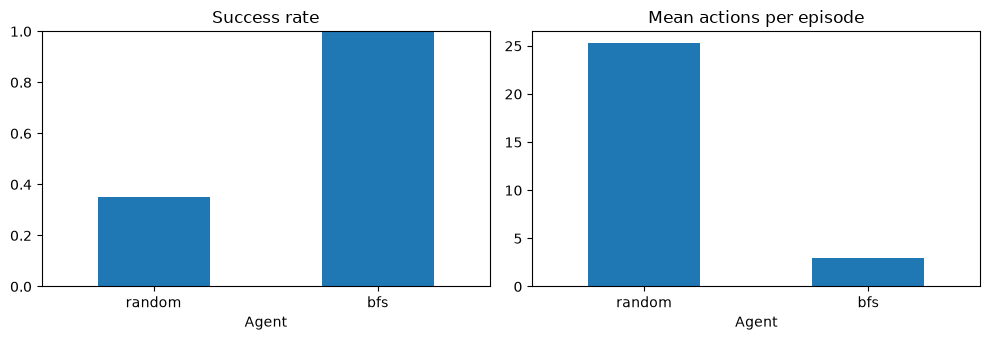

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
summary_df['success_rate'].plot.bar(
    ax=axes[0], ylim=(0, 1), title='Success rate'
)
summary_df['mean_actions'].plot.bar(
    ax=axes[1], title='Mean actions per episode'
)
for axis in axes:
    axis.set_xlabel('Agent')
    axis.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

### 4. Validate the comparison cohort

In [5]:
case_sets = {
    agent_name: set(
        zip(group['level_id'], group['seed'], strict=True)
    )
    for agent_name, group in results_df.groupby('agent_name')
}
assert case_sets['random'] == case_sets['bfs']
assert len(case_sets['bfs']) == len(LEVEL_IDS) * len(SEEDS)
assert summary_df.loc['bfs', 'success_rate'] == 1.0
case_sets

{'bfs': {('tiny-push', 0),
  ('tiny-push', 1),
  ('tiny-push', 2),
  ('tiny-push', 3),
  ('tiny-push', 4),
  ('tiny-push', 5),
  ('tiny-push', 6),
  ('tiny-push', 7),
  ('tiny-push', 8),
  ('tiny-push', 9),
  ('tiny-walk', 0),
  ('tiny-walk', 1),
  ('tiny-walk', 2),
  ('tiny-walk', 3),
  ('tiny-walk', 4),
  ('tiny-walk', 5),
  ('tiny-walk', 6),
  ('tiny-walk', 7),
  ('tiny-walk', 8),
  ('tiny-walk', 9)},
 'random': {('tiny-push', 0),
  ('tiny-push', 1),
  ('tiny-push', 2),
  ('tiny-push', 3),
  ('tiny-push', 4),
  ('tiny-push', 5),
  ('tiny-push', 6),
  ('tiny-push', 7),
  ('tiny-push', 8),
  ('tiny-push', 9),
  ('tiny-walk', 0),
  ('tiny-walk', 1),
  ('tiny-walk', 2),
  ('tiny-walk', 3),
  ('tiny-walk', 4),
  ('tiny-walk', 5),
  ('tiny-walk', 6),
  ('tiny-walk', 7),
  ('tiny-walk', 8),
  ('tiny-walk', 9)}}

## Takeaways

- BFS는 20개 에피소드 중 20개를 해결했다.
- Random은 20개 에피소드 중 7개를 해결했다.
- 이 결과는 작은 내장 레벨 기준선이며, 전체 Boxoban 성능을 대표하지 않는다.